In [13]:
import os
import joblib
import numpy as np
import pandas as pd

def load_encoded(sample_size=12000):
    paths = [
        "data/processed/encoded.pkl",
        "../data/processed/encoded.pkl",
        "../../data/processed/encoded.pkl"
    ]

    for path in paths:
        if os.path.exists(path):
            print(f"✅ Loading from: {path}")
            df = joblib.load(path)
            break
    else:
        raise FileNotFoundError("Run encoding.py first")

    return df.sample(n=min(sample_size, len(df)), random_state=42)

In [14]:
df = load_encoded()

target = "defects"

X = df.drop(columns=[target]).values.astype(np.float32)
y = df[target].values.astype(np.int32)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

✅ Loading from: ../data/processed/encoded.pkl


In [15]:
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.utils.class_weight import compute_class_weight

# SMOTE
smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_train, y_train)

# ADASYN
adasyn = ADASYN(random_state=42)
X_ad, y_ad = adasyn.fit_resample(X_train, y_train)

# Class weights
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

print("Class Weights:", class_weights)

Class Weights: {0: 3.234501347708895, 1: 0.5914243469689502}


In [16]:
def reshape_dl(X):
    return X.reshape(X.shape[0], X.shape[1], 1)

X_train_dl = reshape_dl(X_train)
X_test_dl  = reshape_dl(X_test)

X_sm_dl = reshape_dl(X_sm)
X_ad_dl = reshape_dl(X_ad)

In [17]:
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Conv1D, Flatten, Dense # type: ignore

def build_cnn(input_shape):
    model = Sequential()

    model.add(Conv1D(32, 3, activation="relu", input_shape=input_shape))
    model.add(Flatten())

    model.add(Dense(64, activation="relu"))
    model.add(Dense(32, activation="relu", name="feature_layer"))  # pipeline match

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [18]:
from tensorflow.keras.layers import LSTM # type: ignore

def build_lstm(input_shape):
    model = Sequential()

    model.add(LSTM(32, input_shape=input_shape))
    model.add(Dense(64, activation="relu"))
    model.add(Dense(32, activation="relu", name="feature_layer"))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [19]:
from tensorflow.keras.callbacks import EarlyStopping # type: ignore


def train_model(model_fn, X, y, name, class_weight=None):
    model = model_fn((X.shape[1], 1))

    history = model.fit(
        X,
        y,
        validation_split=0.2,
        epochs=100,
        batch_size=64,
        verbose=1,
        class_weight=class_weight
    )

    return model, history

In [20]:
results = {}

# Original
results["cnn_original"] = train_model(build_cnn, X_train_dl, y_train, "CNN Original")
results["lstm_original"] = train_model(build_lstm, X_train_dl, y_train, "LSTM Original")

# SMOTE
results["cnn_smote"] = train_model(build_cnn, X_sm_dl, y_sm, "CNN SMOTE")
results["lstm_smote"] = train_model(build_lstm, X_sm_dl, y_sm, "LSTM SMOTE")

# ADASYN
results["cnn_adasyn"] = train_model(build_cnn, X_ad_dl, y_ad, "CNN ADASYN")
results["lstm_adasyn"] = train_model(build_lstm, X_ad_dl, y_ad, "LSTM ADASYN")

# Class Weight
results["cnn_weighted"] = train_model(build_cnn, X_train_dl, y_train, "CNN Weighted", class_weights)
results["lstm_weighted"] = train_model(build_lstm, X_train_dl, y_train, "LSTM Weighted", class_weights)

Epoch 1/100
120/120 [==============================] - 1s 4ms/step - loss: 2.4185 - accuracy: 0.9115 - val_loss: 1.0261 - val_accuracy: 0.9417
Epoch 2/100
120/120 [==============================] - 0s 3ms/step - loss: 0.4778 - accuracy: 0.9323 - val_loss: 0.2390 - val_accuracy: 0.9177
Epoch 3/100
120/120 [==============================] - 0s 4ms/step - loss: 0.4724 - accuracy: 0.9358 - val_loss: 0.8155 - val_accuracy: 0.9427
Epoch 4/100
120/120 [==============================] - 0s 3ms/step - loss: 0.4835 - accuracy: 0.9331 - val_loss: 0.4957 - val_accuracy: 0.9438
Epoch 5/100
120/120 [==============================] - 0s 3ms/step - loss: 0.5591 - accuracy: 0.9349 - val_loss: 1.2065 - val_accuracy: 0.9401
Epoch 6/100
120/120 [==============================] - 0s 3ms/step - loss: 0.4583 - accuracy: 0.9349 - val_loss: 0.2114 - val_accuracy: 0.9292
Epoch 7/100
120/120 [==============================] - 0s 3ms/step - loss: 0.3237 - accuracy: 0.9405 - val_loss: 0.1949 - val_accuracy: 0.9323

In [21]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure()
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.title(title)
    plt.legend()
    plt.show()

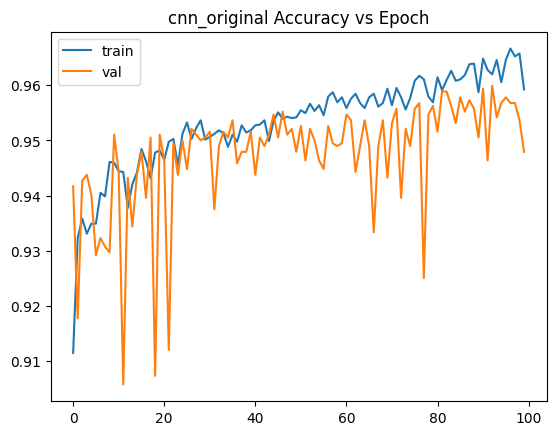

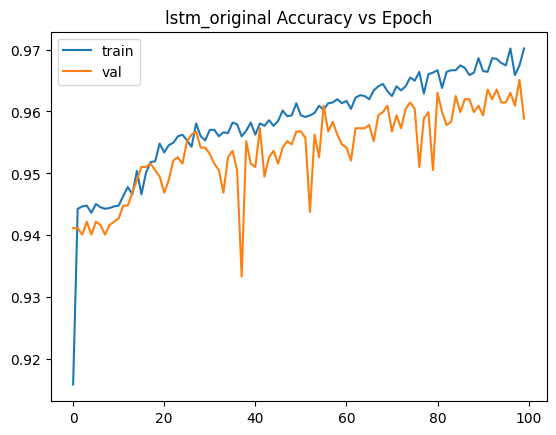

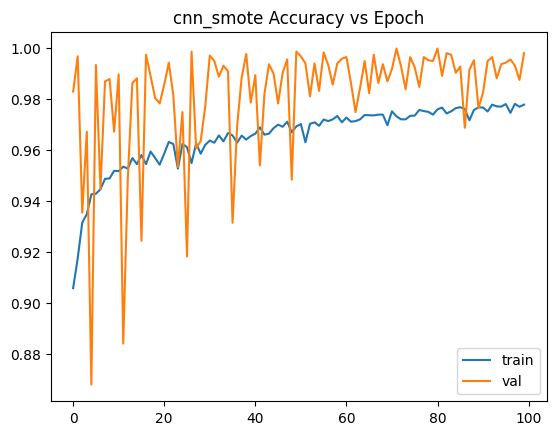

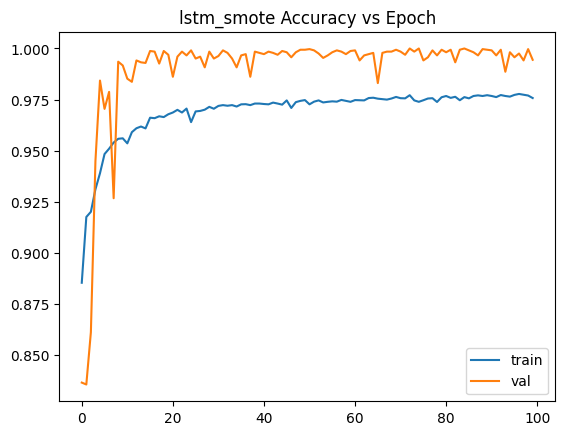

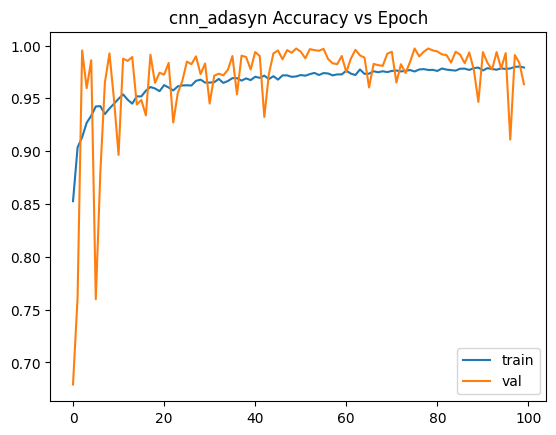

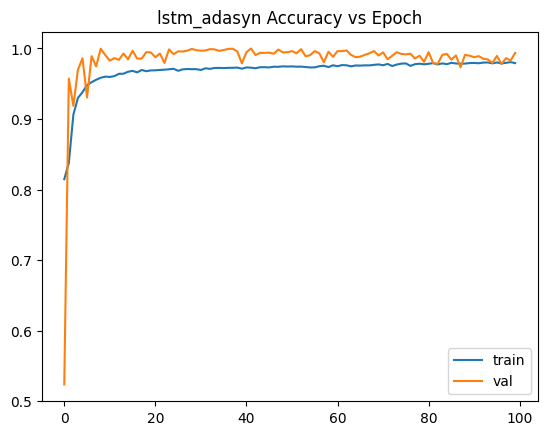

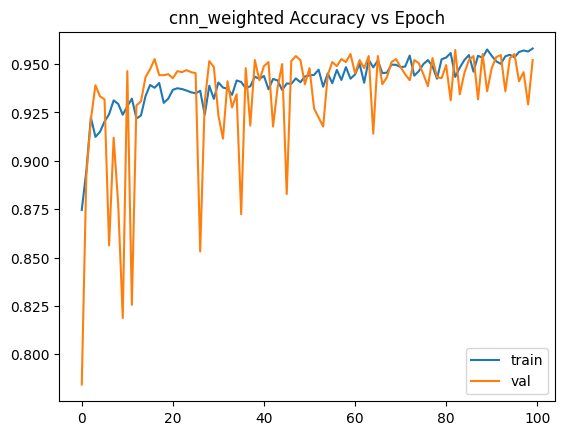

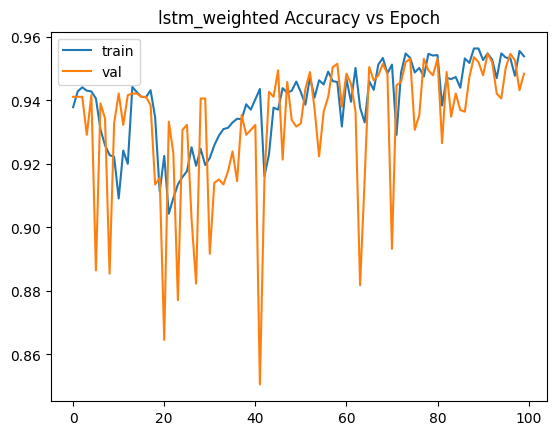

In [22]:
for name, (model, history) in results.items():
    plot_history(history, f"{name} Accuracy vs Epoch")

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate(model, X_test, y_test, name):
    pred = (model.predict(X_test) > 0.5).astype(int)

    print(f"\n==== {name} ====")
    print(classification_report(y_test, pred))

    cm = confusion_matrix(y_test, pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(name)
    plt.show()

75/75 [==============================] - 0s 1ms/step

==== cnn_original ====
              precision    recall  f1-score   support

           0       0.78      0.83      0.80       371
           1       0.97      0.96      0.96      2029

    accuracy                           0.94      2400
   macro avg       0.87      0.89      0.88      2400
weighted avg       0.94      0.94      0.94      2400



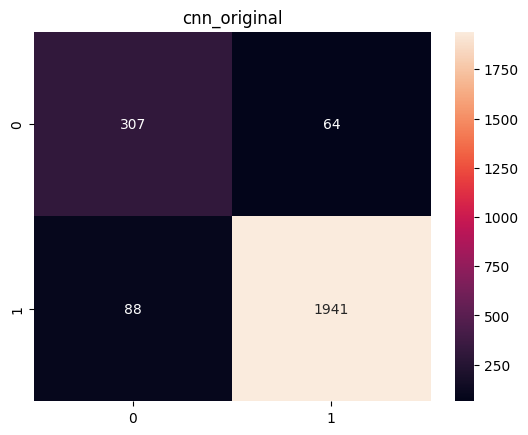

75/75 [==============================] - 1s 3ms/step

==== lstm_original ====
              precision    recall  f1-score   support

           0       0.82      0.92      0.87       371
           1       0.99      0.96      0.97      2029

    accuracy                           0.96      2400
   macro avg       0.90      0.94      0.92      2400
weighted avg       0.96      0.96      0.96      2400



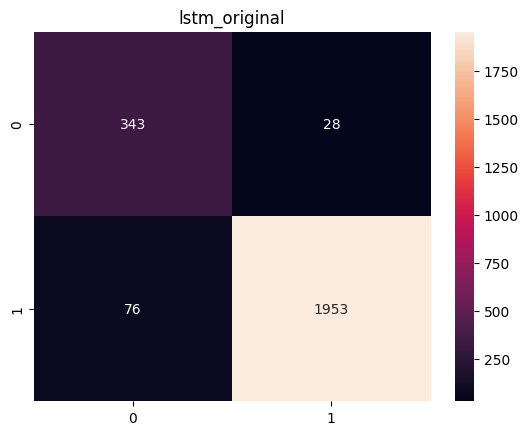

75/75 [==============================] - 0s 2ms/step

==== cnn_smote ====
              precision    recall  f1-score   support

           0       0.78      0.94      0.85       371
           1       0.99      0.95      0.97      2029

    accuracy                           0.95      2400
   macro avg       0.88      0.95      0.91      2400
weighted avg       0.96      0.95      0.95      2400



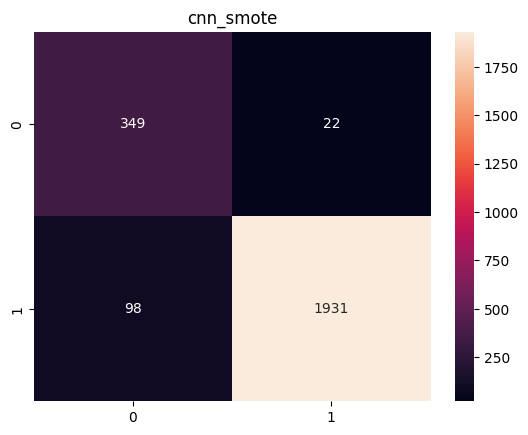

75/75 [==============================] - 1s 4ms/step

==== lstm_smote ====
              precision    recall  f1-score   support

           0       0.78      0.95      0.86       371
           1       0.99      0.95      0.97      2029

    accuracy                           0.95      2400
   macro avg       0.89      0.95      0.91      2400
weighted avg       0.96      0.95      0.95      2400



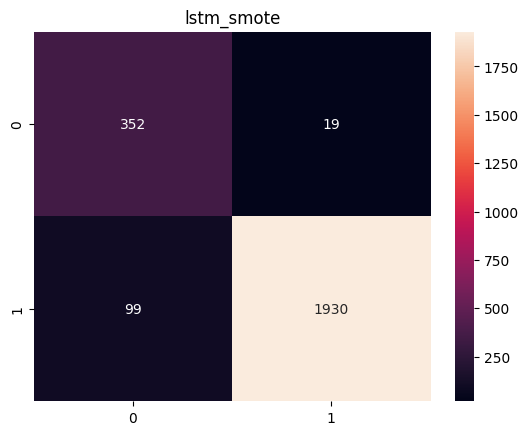

75/75 [==============================] - 0s 2ms/step

==== cnn_adasyn ====
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       371
           1       0.98      0.96      0.97      2029

    accuracy                           0.95      2400
   macro avg       0.89      0.93      0.91      2400
weighted avg       0.95      0.95      0.95      2400



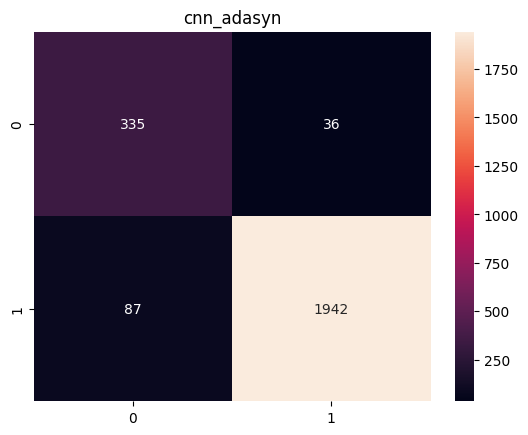

75/75 [==============================] - 1s 4ms/step

==== lstm_adasyn ====
              precision    recall  f1-score   support

           0       0.80      0.95      0.87       371
           1       0.99      0.96      0.97      2029

    accuracy                           0.95      2400
   macro avg       0.89      0.95      0.92      2400
weighted avg       0.96      0.95      0.96      2400



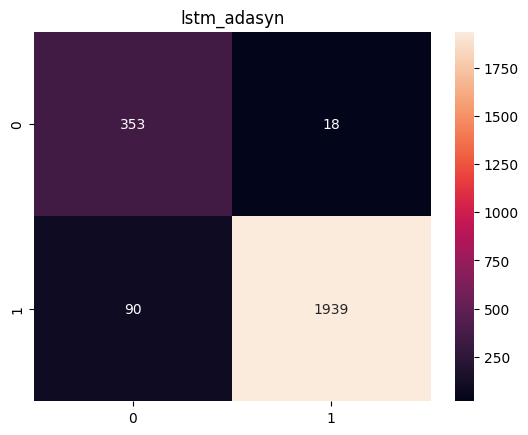

75/75 [==============================] - 0s 1ms/step

==== cnn_weighted ====
              precision    recall  f1-score   support

           0       0.76      0.95      0.84       371
           1       0.99      0.94      0.97      2029

    accuracy                           0.94      2400
   macro avg       0.87      0.95      0.90      2400
weighted avg       0.95      0.94      0.95      2400



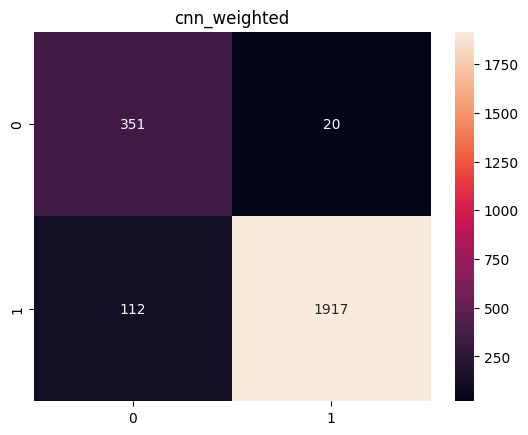

75/75 [==============================] - 1s 4ms/step

==== lstm_weighted ====
              precision    recall  f1-score   support

           0       0.75      0.98      0.85       371
           1       1.00      0.94      0.97      2029

    accuracy                           0.95      2400
   macro avg       0.87      0.96      0.91      2400
weighted avg       0.96      0.95      0.95      2400



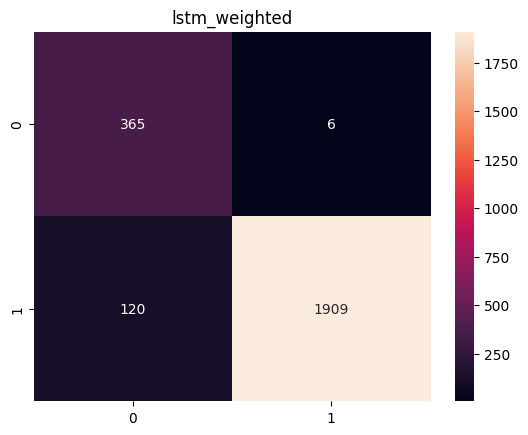

In [24]:
for name, (model, _) in results.items():
    evaluate(model, X_test_dl, y_test, name)

In [25]:
from sklearn.metrics import roc_curve, auc

def plot_roc(model, X_test, y_test, name):
    prob = model.predict(X_test)

    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"{name} AUC={roc_auc:.2f}")
    plt.plot([0,1],[0,1],'--')
    plt.legend()
    plt.title(name)
    plt.show()

75/75 [==============================] - 0s 1ms/step


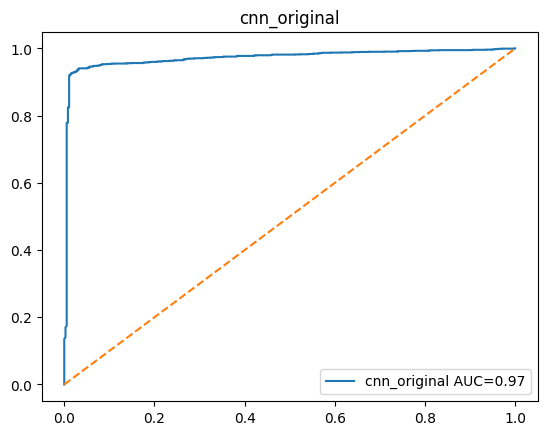

75/75 [==============================] - 0s 3ms/step


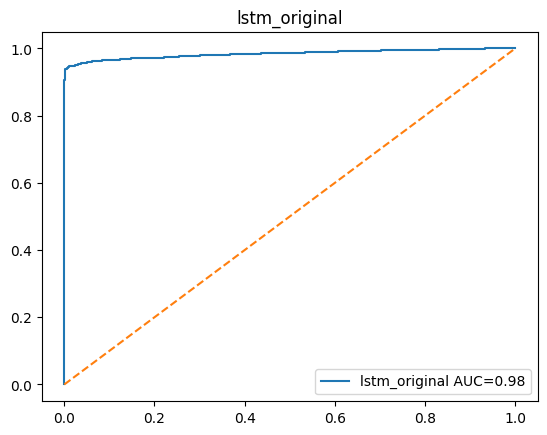

75/75 [==============================] - 0s 2ms/step


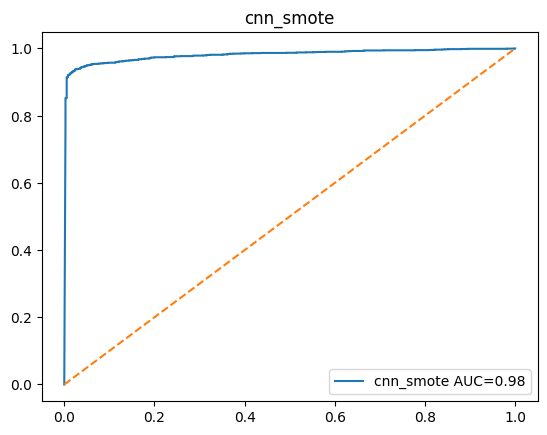

75/75 [==============================] - 0s 4ms/step


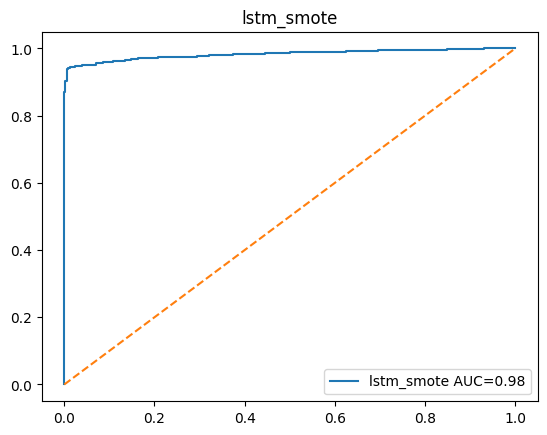

75/75 [==============================] - 0s 1ms/step


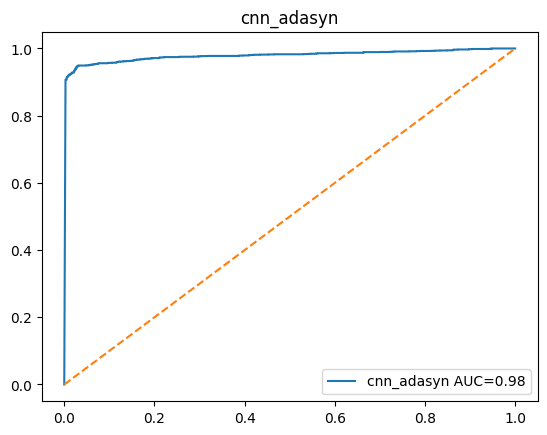

75/75 [==============================] - 0s 3ms/step


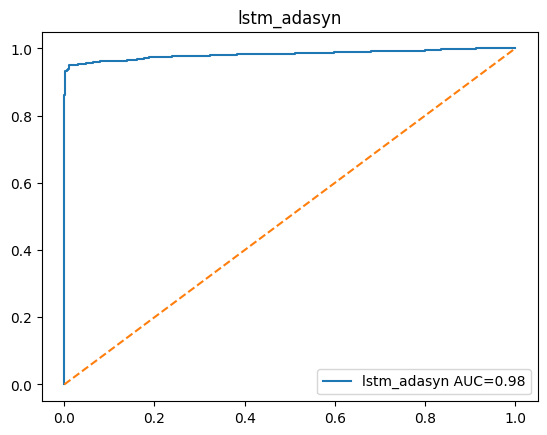

75/75 [==============================] - 0s 1ms/step


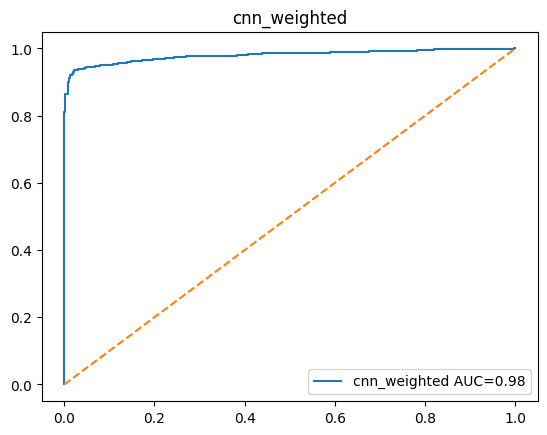

75/75 [==============================] - 0s 4ms/step


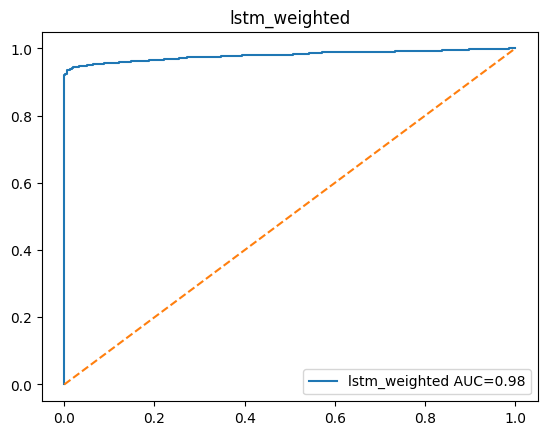

In [26]:
for name, (model, _) in results.items():
    plot_roc(model, X_test_dl, y_test, name)